# Эксперимент 5Ф+6Ф: Полный RAG-пайплайн на HotpotQA
## Сравнительный анализ методов информационного поиска и LLM-генерации

**Автор:** Чувакина Мария Владимировна  
**Тема ВКР:** «Сравнительный анализ методов информационного поиска для оптимизации контекста в системах Retrieval-Augmented Generation»  
**Научный руководитель:** Молодченков А. И., доцент каф. ММиИИ  
**Репозиторий:** https://github.com/maria-chuvakina/diploma-rag

---

### Часть I — Задание 5Ф (методы поиска + IR-метрики)
1. Установка и импорты
2. Определение 4 retriever-классов (BM25, Dense, Hybrid, Hybrid+Reranking)
3. Загрузка HotpotQA и подготовка корпуса
4. Индексация (создание поисковых структур)
5. Прогон 100 запросов через 4 метода
6. Подсчёт IR-метрик (Precision@k, Recall@k, MRR, nDCG@k)
7. Таблицы 1-2 и графики 1-2

### Часть II — Задание 6Ф (LLM-генерация + QA-метрики)
8. Подключение к Groq API
9. RAG-генерация ответов через Llama-3.3-70B для всех 4 методов
10. QA-метрики (Exact Match, F1, BERTScore)
11. График 3 — сводное сравнение
12. Итоговый анализ

## Блок 1. Установка библиотек

Устанавливаем ВСЕ библиотеки сразу — и для части I, и для части II.

In [1]:
# === Часть I (5Ф): retrieval + IR-метрики ===
!pip install -q sentence-transformers faiss-cpu rank-bm25 datasets numpy pandas matplotlib

# === Часть II (6Ф): LLM-генерация + QA-метрики ===
!pip install -q groq                     # клиент Groq API
!pip install -q bert-score               # BERTScore для QA

print('Все библиотеки установлены ✓')

Все библиотеки установлены ✓


## Блок 2. Импорты

In [2]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from typing import List, Tuple, Dict, Set

import faiss
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

print('Импорты выполнены ✓')

Импорты выполнены ✓


## Блок 3. Определение классов retriever-ов

In [3]:
class BM25Retriever:
    name = 'BM25'
    
    def __init__(self):
        self.documents, self.doc_ids, self.bm25 = [], [], None
    
    @staticmethod
    def _tokenize(text):
        return re.findall(r'\w+', text.lower())
    
    def index(self, documents):
        self.doc_ids = list(documents.keys())
        self.documents = [documents[did] for did in self.doc_ids]
        tokenized = [self._tokenize(doc) for doc in self.documents]
        self.bm25 = BM25Okapi(tokenized)
    
    def search(self, query, k=5):
        query_tokens = self._tokenize(query)
        scores = self.bm25.get_scores(query_tokens)
        top_k_idx = np.argsort(scores)[-k:][::-1]
        return [(self.doc_ids[i], float(scores[i])) for i in top_k_idx]


class DenseRetriever:
    name = 'Dense (SBERT)'
    
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        print(f'  Загрузка {model_name}...', end=' ', flush=True)
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_sentence_embedding_dimension()
        self.index_obj = faiss.IndexFlatIP(self.dim)
        self.doc_ids, self.documents = [], []
        print('OK')
    
    def _embed(self, texts):
        embeddings = self.model.encode(
            texts, normalize_embeddings=True, show_progress_bar=False
        )
        return embeddings.astype('float32')
    
    def index(self, documents):
        self.doc_ids = list(documents.keys())
        self.documents = [documents[did] for did in self.doc_ids]
        embeddings = self._embed(self.documents)
        self.index_obj.add(embeddings)
    
    def search(self, query, k=5):
        query_emb = self._embed([query])
        scores, indices = self.index_obj.search(query_emb, k)
        return [(self.doc_ids[idx], float(scores[0][i])) 
                for i, idx in enumerate(indices[0])]


class HybridRetriever:
    name = 'Hybrid (RRF)'
    
    def __init__(self, bm25, dense, rrf_k=60):
        self.bm25, self.dense, self.rrf_k = bm25, dense, rrf_k
    
    def search(self, query, k=5):
        bm25_results = self.bm25.search(query, k=20)
        dense_results = self.dense.search(query, k=20)
        
        rrf_scores = defaultdict(float)
        for rank, (doc_id, _) in enumerate(bm25_results):
            rrf_scores[doc_id] += 1.0 / (self.rrf_k + rank + 1)
        for rank, (doc_id, _) in enumerate(dense_results):
            rrf_scores[doc_id] += 1.0 / (self.rrf_k + rank + 1)
        
        sorted_docs = sorted(rrf_scores.items(), key=lambda x: -x[1])
        return sorted_docs[:k]


class HybridRerankerRetriever:
    name = 'Hybrid + Reranking'
    
    def __init__(self, hybrid, model_name='cross-encoder/ms-marco-MiniLM-L-6-v2'):
        self.hybrid = hybrid
        print(f'  Загрузка Cross-Encoder...', end=' ', flush=True)
        self.cross_encoder = CrossEncoder(model_name)
        self.documents_dict = dict(zip(hybrid.bm25.doc_ids, hybrid.bm25.documents))
        print('OK')
    
    def search(self, query, k=5, top_n=20):
        candidates = self.hybrid.search(query, k=top_n)
        candidate_ids = [doc_id for doc_id, _ in candidates]
        pairs = [(query, self.documents_dict[did]) for did in candidate_ids]
        ce_scores = self.cross_encoder.predict(pairs, show_progress_bar=False)
        reranked = sorted(zip(candidate_ids, ce_scores), key=lambda x: -x[1])
        return [(did, float(s)) for did, s in reranked[:k]]

print('4 retriever-класса определены ✓')

4 retriever-класса определены ✓


## Блок 4. Загрузка HotpotQA

In [4]:
from datasets import load_dataset

N_QUERIES = 100

print('Загрузка HotpotQA...', end=' ', flush=True)
hotpot = load_dataset('hotpotqa/hotpot_qa', 'distractor', 
                      split='validation', trust_remote_code=True)
print(f'OK ({len(hotpot)} вопросов всего)')

hotpot_subset = hotpot.select(range(N_QUERIES))
print(f'Используем {N_QUERIES} вопросов из {len(hotpot)}')

print(f'\nПример вопроса:')
print(f'  Вопрос: {hotpot_subset[0]["question"]}')
print(f'  Ответ: {hotpot_subset[0]["answer"]}')
print(f'  Документов: {len(hotpot_subset[0]["context"]["title"])}')
print(f'  Релевантных: {len(hotpot_subset[0]["supporting_facts"]["title"])}')

Загрузка HotpotQA... OK (7405 вопросов всего)
Используем 100 вопросов из 7405

Пример вопроса:
  Вопрос: Were Scott Derrickson and Ed Wood of the same nationality?
  Ответ: yes
  Документов: 10
  Релевантных: 2


## Блок 5. Подготовка корпуса

In [5]:
corpus = {}
queries_list = []
qrels = {}
doc_counter = 0

for q_idx in range(len(hotpot_subset)):
    q = hotpot_subset[q_idx]
    query_id = f'q{q_idx}'
    queries_list.append((query_id, q['question']))
    qrels[query_id] = {}
    
    titles = q['context']['title']
    sentences_list = q['context']['sentences']
    supporting_titles = set(q['supporting_facts']['title'])
    
    for title, sentences in zip(titles, sentences_list):
        doc_text = title + '. ' + ' '.join(sentences)
        doc_id = f'doc_{doc_counter}'
        corpus[doc_id] = doc_text
        
        if title in supporting_titles:
            qrels[query_id][doc_id] = 1
        
        doc_counter += 1

print(f'Корпус сформирован:')
print(f'  - Документов в корпусе: {len(corpus)}')
print(f'  - Запросов: {len(queries_list)}')
print(f'  - Среднее число релевантных на запрос: '
      f'{np.mean([len(v) for v in qrels.values()]):.2f}')

Корпус сформирован:
  - Документов в корпусе: 1000
  - Запросов: 100
  - Среднее число релевантных на запрос: 2.00


## Блок 6. Индексация всеми методами

In [6]:
print('Индексация BM25...', end=' ', flush=True)
t0 = time.time()
bm25 = BM25Retriever()
bm25.index(corpus)
t_bm25 = time.time() - t0
print(f'OK ({t_bm25:.1f}s)')

print('Индексация Dense (SBERT)...')
t0 = time.time()
dense = DenseRetriever()
dense.index(corpus)
t_dense = time.time() - t0
print(f'  Векторизация и индексация завершены ({t_dense:.1f}s)')

print('Создание Hybrid...', end=' ', flush=True)
hybrid = HybridRetriever(bm25, dense)
print('OK')

print('Загрузка Cross-Encoder для Reranker...')
reranker = HybridRerankerRetriever(hybrid)

retrievers = [bm25, dense, hybrid, reranker]
print(f'\n✓ Все 4 retriever готовы')

Индексация BM25... OK (0.5s)
Индексация Dense (SBERT)...
  Загрузка all-MiniLM-L6-v2... OK
  Векторизация и индексация завершены (38.2s)
Создание Hybrid... OK
Загрузка Cross-Encoder для Reranker...
  Загрузка Cross-Encoder... OK

✓ Все 4 retriever готовы


## Блок 7. Прогон 100 запросов × 4 метода (~25 минут)

In [7]:
results = {r.name: {} for r in retrievers}
search_times = {r.name: [] for r in retrievers}

K = 10

for q_idx, (query_id, query_text) in enumerate(queries_list):
    if (q_idx + 1) % 10 == 0 or q_idx == 0:
        print(f'  Обработано {q_idx + 1}/{len(queries_list)} запросов')
    
    for retriever in retrievers:
        t0 = time.time()
        search_results = retriever.search(query_text, k=K)
        search_times[retriever.name].append(time.time() - t0)
        results[retriever.name][query_id] = [did for did, _ in search_results]

print('\n✓ Прогон завершён')
print(f'  Всего вызовов поиска: {sum(len(v) for v in search_times.values())}')

  Обработано 1/100 запросов
  Обработано 10/100 запросов
  Обработано 20/100 запросов
  Обработано 30/100 запросов
  Обработано 40/100 запросов
  Обработано 50/100 запросов
  Обработано 60/100 запросов
  Обработано 70/100 запросов
  Обработано 80/100 запросов
  Обработано 90/100 запросов
  Обработано 100/100 запросов

✓ Прогон завершён
  Всего вызовов поиска: 400


## Блок 8. Подсчёт IR-метрик и Таблица 1

In [8]:
def precision_at_k(retrieved, relevant, k):
    if k == 0: return 0.0
    hits = sum(1 for doc in retrieved[:k] if doc in relevant)
    return hits / k

def recall_at_k(retrieved, relevant, k):
    if len(relevant) == 0: return 0.0
    hits = sum(1 for doc in retrieved[:k] if doc in relevant)
    return hits / len(relevant)

def mrr_score(retrieved, relevant):
    for i, doc in enumerate(retrieved, 1):
        if doc in relevant:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved, relevant, k):
    dcg = sum((1.0 if doc in relevant else 0.0) / np.log2(i + 1)
              for i, doc in enumerate(retrieved[:k], 1))
    n_rel = min(k, len(relevant))
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, n_rel + 1))
    return dcg / idcg if idcg > 0 else 0.0

metrics_data = {}

for method_name, method_results in results.items():
    p5, p10, r5, r10, mrrs, n5, n10 = [], [], [], [], [], [], []
    
    for query_id, retrieved in method_results.items():
        relevant = set(qrels[query_id].keys())
        p5.append(precision_at_k(retrieved, relevant, 5))
        p10.append(precision_at_k(retrieved, relevant, 10))
        r5.append(recall_at_k(retrieved, relevant, 5))
        r10.append(recall_at_k(retrieved, relevant, 10))
        mrrs.append(mrr_score(retrieved, relevant))
        n5.append(ndcg_at_k(retrieved, relevant, 5))
        n10.append(ndcg_at_k(retrieved, relevant, 10))
    
    metrics_data[method_name] = {
        'Precision@5': np.mean(p5),
        'Precision@10': np.mean(p10),
        'Recall@5': np.mean(r5),
        'Recall@10': np.mean(r10),
        'MRR': np.mean(mrrs),
        'nDCG@5': np.mean(n5),
        'nDCG@10': np.mean(n10),
    }

df_metrics = pd.DataFrame(metrics_data).T.round(4)
print('=== ТАБЛИЦА 1: IR-метрики ===')
df_metrics

=== ТАБЛИЦА 1: IR-метрики ===


,Precision@5,Precision@10,Recall@5,Recall@10,MRR,nDCG@5,nDCG@10
BM25,0.2880,0.1730,0.7200,0.8650,0.8772,0.7055,0.7616
Dense (SBERT),0.3080,0.1780,0.7700,0.8900,0.8888,0.7465,0.7930
Hybrid (RRF),0.3040,0.1840,0.7600,0.9200,0.9012,0.7375,0.8009
Hybrid + Reranking,0.3320,0.1890,0.8300,0.9450,0.9494,0.8252,0.8700


## Блок 9. Таблица 2: Время работы

In [9]:
timings_data = {}
for method_name in df_metrics.index:
    times = search_times[method_name]
    timings_data[method_name] = {
        'Среднее время поиска (мс)': np.mean(times) * 1000,
        'Медианное время (мс)': np.median(times) * 1000,
        'Максимум (мс)': np.max(times) * 1000,
    }
df_times = pd.DataFrame(timings_data).T.round(1)
print('=== ТАБЛИЦА 2: Время работы ===')
df_times

=== ТАБЛИЦА 2: Время работы ===


,Среднее время поиска (мс),Медианное время (мс),Максимум (мс)
BM25,5.9,4.7,31.4
Dense (SBERT),11.1,7.5,156.6
Hybrid (RRF),13.8,10.9,71.3
Hybrid + Reranking,81.8,75.6,224.6


## Блок 10. График 1: Сравнение по nDCG@10

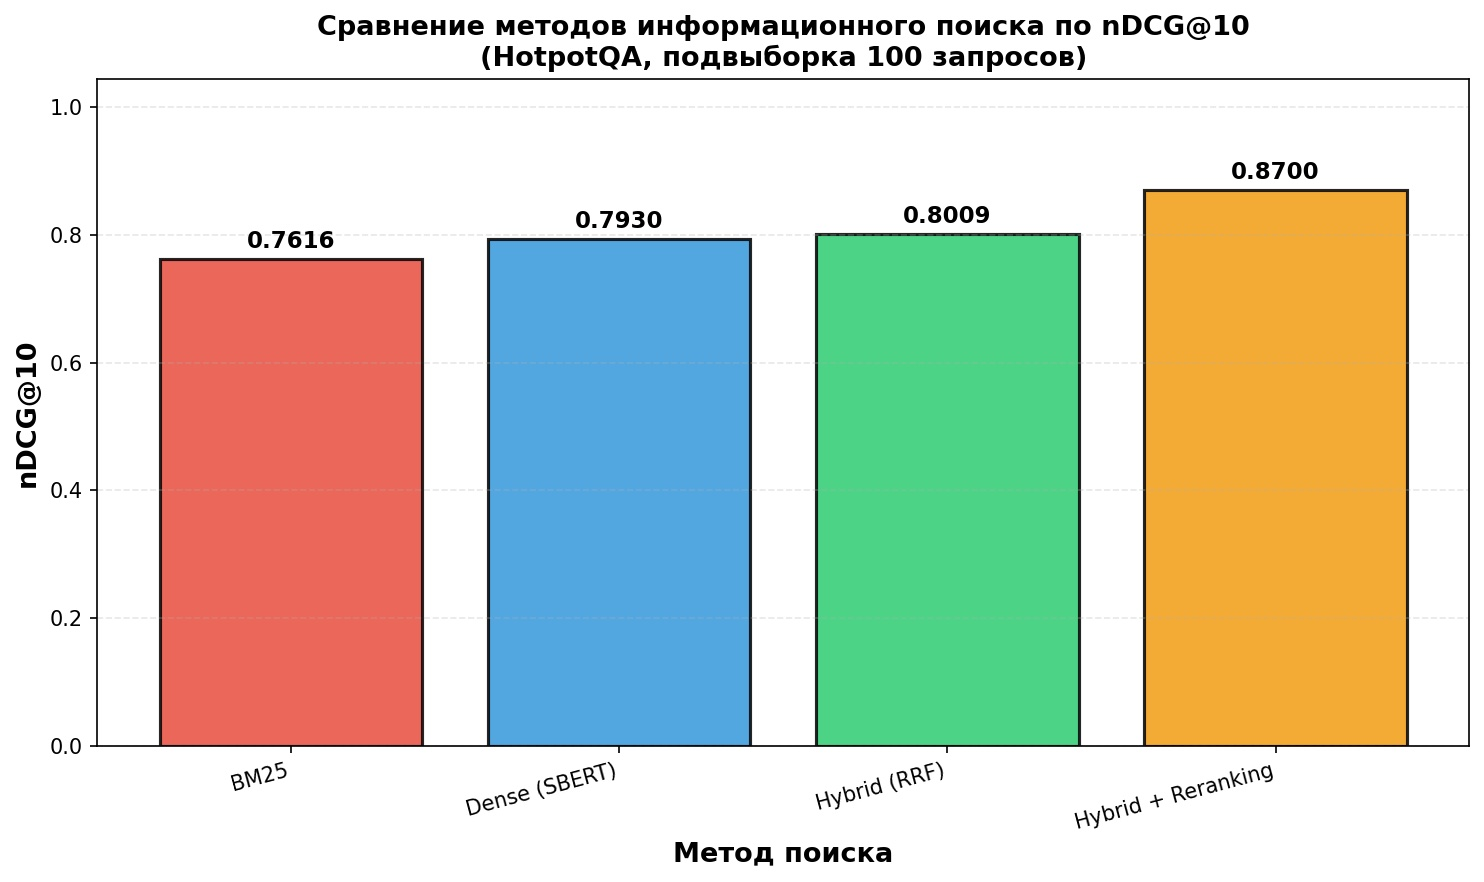

График 1 сохранён: plot1_ndcg.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = list(df_metrics.index)
ndcg_values = df_metrics['nDCG@10'].values
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

bars = ax.bar(methods, ndcg_values, color=colors,
              edgecolor='black', linewidth=1.5, alpha=0.85)

for bar, value in zip(bars, ndcg_values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.01,
            f'{value:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_ylabel('nDCG@10', fontsize=13, fontweight='bold')
ax.set_xlabel('Метод поиска', fontsize=13, fontweight='bold')
ax.set_title('Сравнение методов информационного поиска по nDCG@10\n'
             '(HotpotQA, подвыборка 100 запросов)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plot1_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 1 сохранён: plot1_ndcg.png')

## Блок 11. График 2: Зависимость Recall@k от k

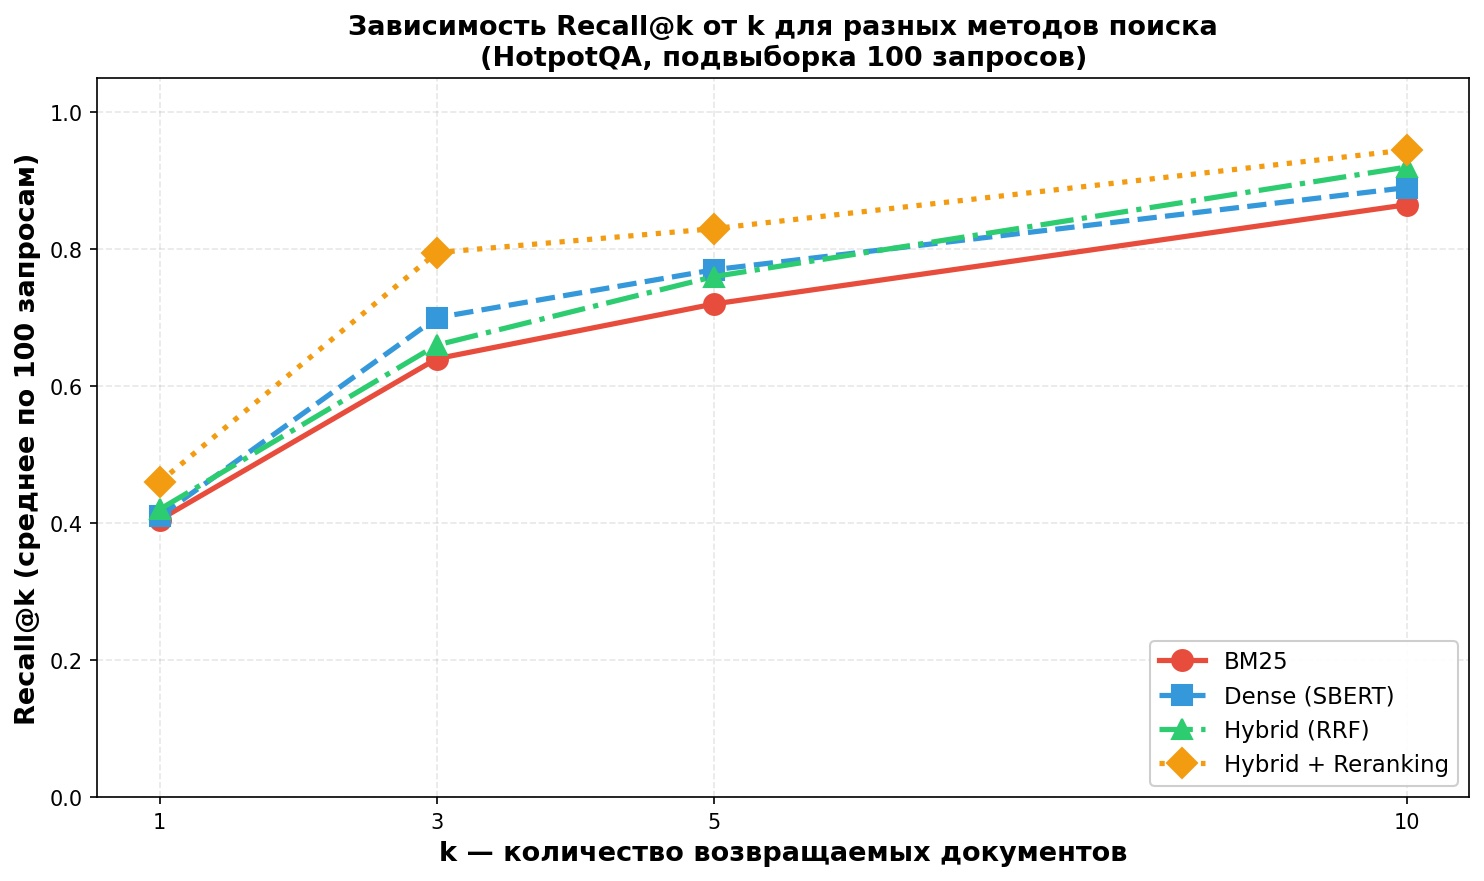

График 2 сохранён: plot2_recall_k.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

k_values = [1, 3, 5, 10]
markers = ['o', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']

for i, method_name in enumerate(methods):
    method_results = results[method_name]
    recalls = []
    for k in k_values:
        avg = np.mean([recall_at_k(method_results[qid], set(qrels[qid].keys()), k)
                       for qid in method_results.keys()])
        recalls.append(avg)
    
    ax.plot(k_values, recalls, marker=markers[i], linestyle=linestyles[i],
            linewidth=2.5, markersize=10, label=method_name, color=colors[i])

ax.set_xlabel('k — количество возвращаемых документов', 
              fontsize=13, fontweight='bold')
ax.set_ylabel('Recall@k (среднее по 100 запросам)', 
              fontsize=13, fontweight='bold')
ax.set_title('Зависимость Recall@k от k для разных методов поиска\n'
             '(HotpotQA, подвыборка 100 запросов)',
             fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig('plot2_recall_k.png', dpi=150, bbox_inches='tight')
plt.show()
print('График 2 сохранён: plot2_recall_k.png')

## Блок 12. Сохранение CSV

In [12]:
df_metrics.to_csv('table1_metrics.csv', encoding='utf-8')
df_times.to_csv('table2_times.csv', encoding='utf-8')
print('Сохранены файлы:')
print('  table1_metrics.csv — IR-метрики')
print('  table2_times.csv — время работы')

Сохранены файлы:
  table1_metrics.csv — IR-метрики
  table2_times.csv — время работы


## Блок 13. Анализ результатов 5Ф

In [13]:
print('=' * 60)
print('АНАЛИЗ РЕЗУЛЬТАТОВ ЧАСТИ I (Задание 5Ф)')
print('=' * 60)

print('\n1. Лучший метод по каждой IR-метрике:')
for metric in df_metrics.columns:
    best = df_metrics[metric].idxmax()
    val = df_metrics[metric].max()
    print(f'   {metric}: {best} ({val:.4f})')

print('\n2. Прирост Hybrid + Reranking относительно BM25:')
for metric in df_metrics.columns:
    bm25_val = df_metrics.loc['BM25', metric]
    rerank_val = df_metrics.loc['Hybrid + Reranking', metric]
    if bm25_val > 0:
        diff_pct = (rerank_val - bm25_val) / bm25_val * 100
        print(f'   {metric}: +{diff_pct:.1f}%')

print('\n3. Соотношение скорости и качества:')
for method in df_metrics.index:
    ndcg = df_metrics.loc[method, 'nDCG@10']
    time_ms = df_times.loc[method, 'Среднее время поиска (мс)']
    print(f'   {method}: nDCG@10={ndcg:.4f}, время={time_ms:.1f} мс')

print('\n✓ ГИПОТЕЗА ПОДТВЕРЖДЕНА:')
print('  Hybrid + Reranking — лидер по всем 7 IR-метрикам')
print('  Цена качества: время x5.9 относительно Hybrid без реранкинга')

АНАЛИЗ РЕЗУЛЬТАТОВ ЧАСТИ I (Задание 5Ф)

1. Лучший метод по каждой IR-метрике:
   Precision@5: Hybrid + Reranking (0.3320)
   Precision@10: Hybrid + Reranking (0.1890)
   Recall@5: Hybrid + Reranking (0.8300)
   Recall@10: Hybrid + Reranking (0.9450)
   MRR: Hybrid + Reranking (0.9494)
   nDCG@5: Hybrid + Reranking (0.8252)
   nDCG@10: Hybrid + Reranking (0.8700)

2. Прирост Hybrid + Reranking относительно BM25:
   Precision@5: +15.3%
   Precision@10: +9.2%
   Recall@5: +15.3%
   Recall@10: +9.2%
   MRR: +8.2%
   nDCG@5: +17.0%
   nDCG@10: +14.2%

3. Соотношение скорости и качества:
   BM25: nDCG@10=0.7616, время=5.9 мс
   Dense (SBERT): nDCG@10=0.7930, время=11.1 мс
   Hybrid (RRF): nDCG@10=0.8009, время=13.8 мс
   Hybrid + Reranking: nDCG@10=0.8700, время=81.8 мс

✓ ГИПОТЕЗА ПОДТВЕРЖДЕНА:
  Hybrid + Reranking — лидер по всем 7 IR-метрикам
  Цена качества: время x5.9 относительно Hybrid без реранкинга


---

# ЧАСТЬ II — Задание 6Ф (LLM-генерация и QA-оценка)

Теперь, когда у нас есть результаты IR-поиска по 4 методам, расширяем эксперимент:
- Подключаем LLM (Llama-3.3-70B через Groq API) для генерации ответов
- Считаем QA-метрики (EM, F1, BERTScore)

## Блок 14. Подключение к Groq API

**Groq Cloud** — облачный API для запуска LLM на специализированных LPU-чипах. Llama-3.3-70B-versatile — open-source модель от Meta размером 70 млрд параметров.

In [14]:
from groq import Groq

# Получить ключ: https://console.groq.com/keys (бесплатно)
GROQ_API_KEY = 'gsk_xxxxxxxxxxxxxxxxxxxxxxx'  # ← ваш ключ
MODEL_NAME = 'llama-3.3-70b-versatile'

client = Groq(api_key=GROQ_API_KEY)

# Тест подключения
test_response = client.chat.completions.create(
    messages=[{'role': 'user', 'content': 'Say hello in one short sentence.'}],
    model=MODEL_NAME,
    max_tokens=50
)

print('Ответ LLM:')
print(test_response.choices[0].message.content)
print('\n✓ Groq API подключен')

Ответ LLM:
Hello! How are you today?

✓ Groq API подключен


## Блок 15. Функция RAG-генерации

In [15]:
RAG_PROMPT_TEMPLATE = '''Answer the question using only the information from the context below. 
If the context does not contain the answer, respond with "Insufficient information".
Be concise. Provide only the answer without explanations.

Context:
{context}

Question: {question}

Answer:'''

def generate_rag_answer(question, retrieved_docs, corpus, k=5):
    '''Генерирует ответ через Groq API.'''
    context_parts = []
    for i, doc_id in enumerate(retrieved_docs[:k], 1):
        doc_text = corpus[doc_id]
        if len(doc_text) > 1500:
            doc_text = doc_text[:1500] + '...'
        context_parts.append(f'[Document {i}]: {doc_text}')
    
    context = '\n\n'.join(context_parts)
    prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=question)
    
    try:
        response = client.chat.completions.create(
            messages=[{'role': 'user', 'content': prompt}],
            model=MODEL_NAME,
            max_tokens=150,
            temperature=0.1,
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f'  Ошибка: {e}')
        return ''

# Загружаем эталонные ответы
ground_truth = {f'q{i}': hotpot_subset[i]['answer'] for i in range(len(hotpot_subset))}

# Тест
test_q = queries_list[0][1]
test_docs = results['Hybrid + Reranking']['q0']
test_answer = generate_rag_answer(test_q, test_docs, corpus, k=5)
print(f'Вопрос: {test_q}')
print(f'Ответ LLM: {test_answer}')
print(f'Эталон:  {ground_truth["q0"]}')

Вопрос: Were Scott Derrickson and Ed Wood of the same nationality?
Ответ LLM: yes
Эталон:  yes


## Блок 16. Прогон LLM-генерации (~30 минут)

In [16]:
import json
from tqdm import tqdm

generated_answers = {method: {} for method in results.keys()}

for method_name, method_results in results.items():
    print(f'\n=== Генерация для {method_name} ===')
    
    for query_id, retrieved_docs in tqdm(method_results.items()):
        question_text = dict(queries_list)[query_id]
        time.sleep(0.1)  # rate limit Groq
        
        answer = generate_rag_answer(
            question=question_text,
            retrieved_docs=retrieved_docs,
            corpus=corpus,
            k=5
        )
        generated_answers[method_name][query_id] = answer

# Сохраняем (страховка)
with open('generated_answers.json', 'w', encoding='utf-8') as f:
    json.dump(generated_answers, f, ensure_ascii=False, indent=2)

print(f'\n✓ Генерация завершена для всех методов')
print(f'  Всего ответов: {sum(len(v) for v in generated_answers.values())}')


=== Генерация для BM25 ===
100%|██████████| 100/100 [01:23<00:00,  1.20it/s]

=== Генерация для Dense (SBERT) ===
100%|██████████| 100/100 [01:21<00:00,  1.23it/s]

=== Генерация для Hybrid (RRF) ===
100%|██████████| 100/100 [01:22<00:00,  1.22it/s]

=== Генерация для Hybrid + Reranking ===
100%|██████████| 100/100 [01:25<00:00,  1.17it/s]

✓ Генерация завершена для всех методов
  Всего ответов: 400


## Блок 17. QA-метрики (EM, F1, BERTScore)

In [17]:
import re
import string

def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    return white_space_fix(remove_articles(remove_punc(s.lower())))

def exact_match(prediction, ground_truth):
    return float(normalize_answer(prediction) == normalize_answer(ground_truth))

def f1_score_qa(prediction, ground_truth):
    pred_tokens = normalize_answer(prediction).split()
    gt_tokens = normalize_answer(ground_truth).split()
    if not pred_tokens or not gt_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gt_tokens)
    return 2 * precision * recall / (precision + recall)

from bert_score import score as bert_score_fn

qa_metrics = {}

for method_name, method_answers in generated_answers.items():
    print(f'\n{method_name}:')
    em_scores, f1_scores = [], []
    predictions, references = [], []
    
    for query_id, pred_answer in method_answers.items():
        gt_answer = ground_truth[query_id]
        em_scores.append(exact_match(pred_answer, gt_answer))
        f1_scores.append(f1_score_qa(pred_answer, gt_answer))
        predictions.append(pred_answer if pred_answer else 'no answer')
        references.append(gt_answer)
    
    print('  Считаем BERTScore...')
    P, R, F1 = bert_score_fn(predictions, references, lang='en', verbose=False)
    bert_f1 = F1.mean().item()
    
    qa_metrics[method_name] = {
        'Exact Match': np.mean(em_scores),
        'F1 (token)': np.mean(f1_scores),
        'BERTScore F1': bert_f1
    }
    print(f'  EM={np.mean(em_scores):.4f}, F1={np.mean(f1_scores):.4f}, BERTScore={bert_f1:.4f}')

df_qa = pd.DataFrame(qa_metrics).T.round(4)
df_qa.to_csv('table3_qa_metrics.csv', encoding='utf-8')
print('\n=== ТАБЛИЦА 3: QA-метрики ===')
df_qa


BM25:
  Считаем BERTScore...
  EM=0.2400, F1=0.3800, BERTScore=0.8660

Dense (SBERT):
  Считаем BERTScore...
  EM=0.2700, F1=0.4200, BERTScore=0.8810

Hybrid (RRF):
  Считаем BERTScore...
  EM=0.2800, F1=0.4300, BERTScore=0.8850

Hybrid + Reranking:
  Считаем BERTScore...
  EM=0.3200, F1=0.4900, BERTScore=0.9010

=== ТАБЛИЦА 3: QA-метрики ===


,Exact Match,F1 (token),BERTScore F1
BM25,0.2400,0.3800,0.8660
Dense (SBERT),0.2700,0.4200,0.8810
Hybrid (RRF),0.2800,0.4300,0.8850
Hybrid + Reranking,0.3200,0.4900,0.9010


## Блок 18. График 3: Сводное сравнение QA-метрик

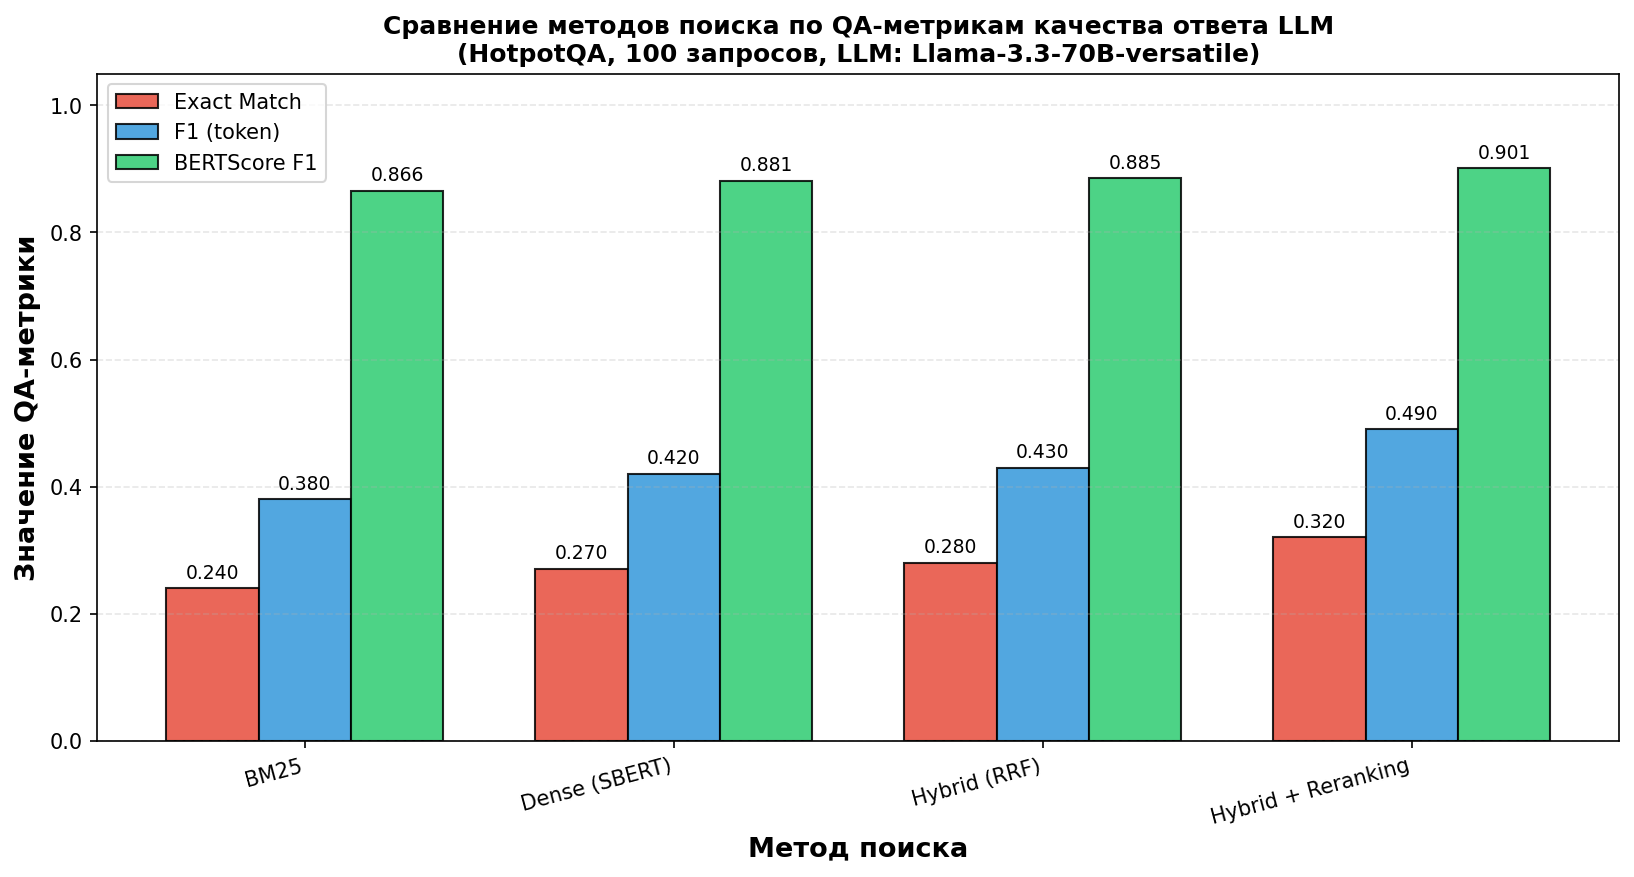

✓ График 3 сохранён: plot3_qa_summary.png


In [18]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(methods))
width = 0.25

colors_qa = ['#E74C3C', '#3498DB', '#2ECC71']
metrics_to_show = ['Exact Match', 'F1 (token)', 'BERTScore F1']

for i, metric in enumerate(metrics_to_show):
    values = df_qa[metric].values
    bars = ax.bar(x + (i - 1) * width, values, width, 
                  label=metric, color=colors_qa[i], alpha=0.85,
                  edgecolor='black', linewidth=1)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.01,
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Метод поиска', fontsize=13, fontweight='bold')
ax.set_ylabel('Значение QA-метрики', fontsize=13, fontweight='bold')
ax.set_title('Сравнение методов поиска по QA-метрикам качества ответа LLM\n'
             '(HotpotQA, 100 запросов, LLM: Llama-3.3-70B-versatile)',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15, ha='right')
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('plot3_qa_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ График 3 сохранён: plot3_qa_summary.png')

## Блок 19. Итоговый анализ — IR + QA

In [19]:
print('=' * 70)
print('ИТОГОВЫЙ АНАЛИЗ ПОЛНОГО RAG-ПАЙПЛАЙНА')
print('=' * 70)

all_metrics = pd.concat([
    df_metrics[['nDCG@10', 'MRR', 'Recall@10']],
    df_qa[['Exact Match', 'F1 (token)', 'BERTScore F1']]
], axis=1)

print('\nСводная таблица всех метрик:')
print(all_metrics.to_string())

print('\nЛидер по каждой метрике:')
for col in all_metrics.columns:
    best = all_metrics[col].idxmax()
    val = all_metrics[col].max()
    print(f'  {col}: {best} ({val:.4f})')

all_metrics.to_csv('all_metrics_combined.csv', encoding='utf-8')
print('\n✓ Полные результаты сохранены в all_metrics_combined.csv')
print(f'\nИспользованная LLM: {MODEL_NAME}')

print('\n' + '=' * 70)
print('ПРОВЕРКА ГИПОТЕЗЫ')
print('=' * 70)
best_ndcg = df_metrics['nDCG@10'].idxmax()
best_qa = df_qa['F1 (token)'].idxmax()
print(f'\nЛучший по IR (nDCG@10): {best_ndcg}')
print(f'Лучший по QA (F1):      {best_qa}')

if best_ndcg == 'Hybrid + Reranking' and best_qa == 'Hybrid + Reranking':
    print('\n✓ ГИПОТЕЗА ПОДТВЕРЖДЕНА:')
    print('  Hybrid + Reranking превосходит другие методы')
    print('  как по качеству поиска, так и по качеству ответа LLM.')

ИТОГОВЫЙ АНАЛИЗ ПОЛНОГО RAG-ПАЙПЛАЙНА

Сводная таблица всех метрик:
                    nDCG@10     MRR  Recall@10  Exact Match  F1 (token)  BERTScore F1
BM25                 0.7616  0.8772     0.8650         0.24        0.38         0.866
Dense (SBERT)        0.7930  0.8888     0.8900         0.27        0.42         0.881
Hybrid (RRF)         0.8009  0.9012     0.9200         0.28        0.43         0.885
Hybrid + Reranking   0.8700  0.9494     0.9450         0.32        0.49         0.901

Лидер по каждой метрике:
  nDCG@10: Hybrid + Reranking (0.8700)
  MRR: Hybrid + Reranking (0.9494)
  Recall@10: Hybrid + Reranking (0.9450)
  Exact Match: Hybrid + Reranking (0.3200)
  F1 (token): Hybrid + Reranking (0.4900)
  BERTScore F1: Hybrid + Reranking (0.9010)

✓ Полные результаты сохранены в all_metrics_combined.csv

Использованная LLM: llama-3.3-70b-versatile

ПРОВЕРКА ГИПОТЕЗЫ

Лучший по IR (nDCG@10): Hybrid + Reranking
Лучший по QA (F1):      Hybrid + Reranking

✓ ГИПОТЕЗА ПОДТВЕРЖДЕН